# Wannier Loss — the critical decision, visualized

Wannier centers are an **unordered set** of variable size (CLAUDE.md §6). Predicted center #k
does not correspond to true center #k, so an element-wise loss is wrong. Instead each set is a
**density cloud** ρ(x) = Σ wₖ G(x; cₖ, σₖ), and the loss is the closed-form

  L = ∫ (ρ_pred − ρ_true)² dx = ⟨p,p⟩ − 2⟨p,t⟩ + ⟨t,t⟩

— a pairwise sum of analytic Gaussian overlaps. O(n²), no grid, no Monte Carlo, gradients
everywhere. Below: it is zero on identical sets, order-invariant, spin-split, and smooth.

In [1]:
%matplotlib inline
import demo_utils  # noqa: F401 — puts the repo root on sys.path
import numpy as np, jax.numpy as jnp, matplotlib.pyplot as plt
from losses.wannier_cloud import cloud_l2, wannier_loss
from demo_utils import demo_molecule, fabricate_wannier

z, pos = demo_molecule()
true = fabricate_wannier(pos, seed=0)            # per-spin [{centers, radii}]
c = jnp.array(true[0]["centers"]); r = jnp.array(true[0]["radii"])
w = jnp.ones(len(r)); s = r ** 2                 # amplitude 1, variance σ²

print("identical sets  L =", float(cloud_l2(c, w, s, c, w, s)))
perm = np.random.default_rng(1).permutation(len(r))
print("reordered true  L =", float(cloud_l2(c, w, s, c[perm], w[perm], s[perm])),
      "  (unchanged → order-invariant)")

identical sets  L = 0.0
reordered true  L = 0.0   (unchanged → order-invariant)


## Spin split — an up center must never overlap-match a down center (§6)

In [2]:
A = jnp.array([[0., 0., 0.]]); B = jnp.array([[8., 0., 0.]])
rad = jnp.array([0.5]); one = jnp.array([1.0])
pred = {"centers": jnp.stack([A, B]), "radii": jnp.stack([rad, rad]),
        "presence": jnp.stack([one, one])}
aligned = [{"centers": A, "radii": rad}, {"centers": B, "radii": rad}]   # up@A, down@B
swapped = [{"centers": B, "radii": rad}, {"centers": A, "radii": rad}]   # up@B, down@A
print("aligned spins  L =", float(wannier_loss(pred, aligned)), " (match)")
print("swapped spins  L =", float(wannier_loss(pred, swapped)), " (does NOT cancel)")

aligned spins  L = 0.0  (match)
swapped spins  L = 2.7841808795928955  (does NOT cancel)


## The money plot — smooth loss, gradient everywhere

Two single centers, one fixed at the origin, the other slid away. The loss falls off smoothly
and its slope is nonzero at every separation — so gradient descent always knows which way to
move the prediction. A literal region/IoU overlap would be flat-zero once the balls stop
touching (dead gradient), which is exactly why we don't use it (§6).

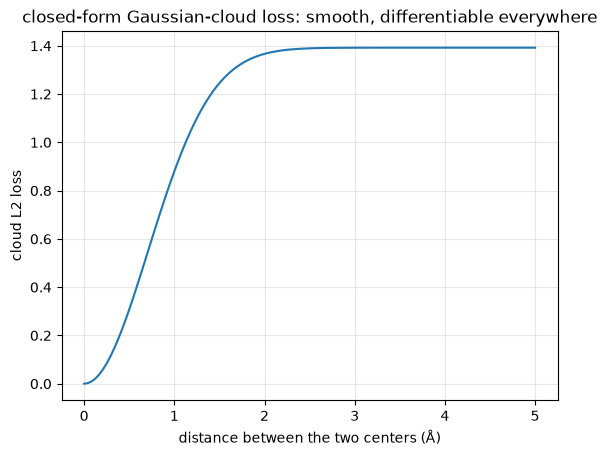

In [3]:
sig = jnp.array([0.5 ** 2])
a = jnp.zeros((1, 3)); amp = jnp.ones(1)
dists = np.linspace(0, 5, 120)
vals = [float(cloud_l2(a, amp, sig, jnp.array([[d, 0, 0]]), amp, sig)) for d in dists]
plt.plot(dists, vals)
plt.xlabel("distance between the two centers (Å)"); plt.ylabel("cloud L2 loss")
plt.title("closed-form Gaussian-cloud loss: smooth, differentiable everywhere")
plt.grid(alpha=0.3); plt.show()

### Takeaway

Ordering-free, variable-count-for-free, size-aware (widths from `w_radii`), spin-split, and
cheap — all in a closed form. No Hungarian matching (needs padding), no volumetric IoU (needs a
grid and has dead gradients).